Saving output.csv to output.csv

REAL DATASET SHAPE:
(20411, 6)

REAL DATASET COLUMNS:

['mos', 'throughput', 'avg_bitrate', 'delay_qos', 'jitter', 'packet_loss']

UPDATED COLUMNS:

['mos', 'throughput', 'avg_bitrate', 'delay', 'jitter', 'packet_loss']

SYNTHETIC DATASET SHAPE:
(22000, 6)

COMBINED DATASET SHAPE:
(42411, 6)

AFTER CLEANING:
(41566, 6)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


832/832 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.5470 - mae: 0.5470 - mos_accuracy: 0.6063 - val_loss: 0.4079 - val_mae: 0.4079 - val_mos_accuracy: 0.7399
Epoch 2/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.4109 - mae: 0.4109 - mos_accuracy: 0.7244 - val_loss: 0.3531 - val_mae: 0.3531 - val_mos_accuracy: 0.7690
Epoch 3/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.3678 - mae: 0.3678 - mos_accuracy: 0.7670 - val_loss: 0.3788 - val_mae: 0.3788 - val_mos_accuracy: 0.7773
Epoch 4/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.3549 - mae: 0.3549 - mos_accuracy: 0.7718 - val_loss: 0.3403 - val_mae: 0.3403 - val_mos_accuracy: 0.7809
Epoch 5/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.3486 - mae: 0.3486 - mos_accuracy: 0.7743 - val_loss: 0.3363 - val_mae: 0.3363 - val_mos_accuracy: 0.7632
Epoch 6/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.3417 - mae: 0.3417 - mos_accuracy: 0.7731 - val_loss: 0.3406 - val_mae: 0.3406 - val_mos_accuracy: 0.7786
E

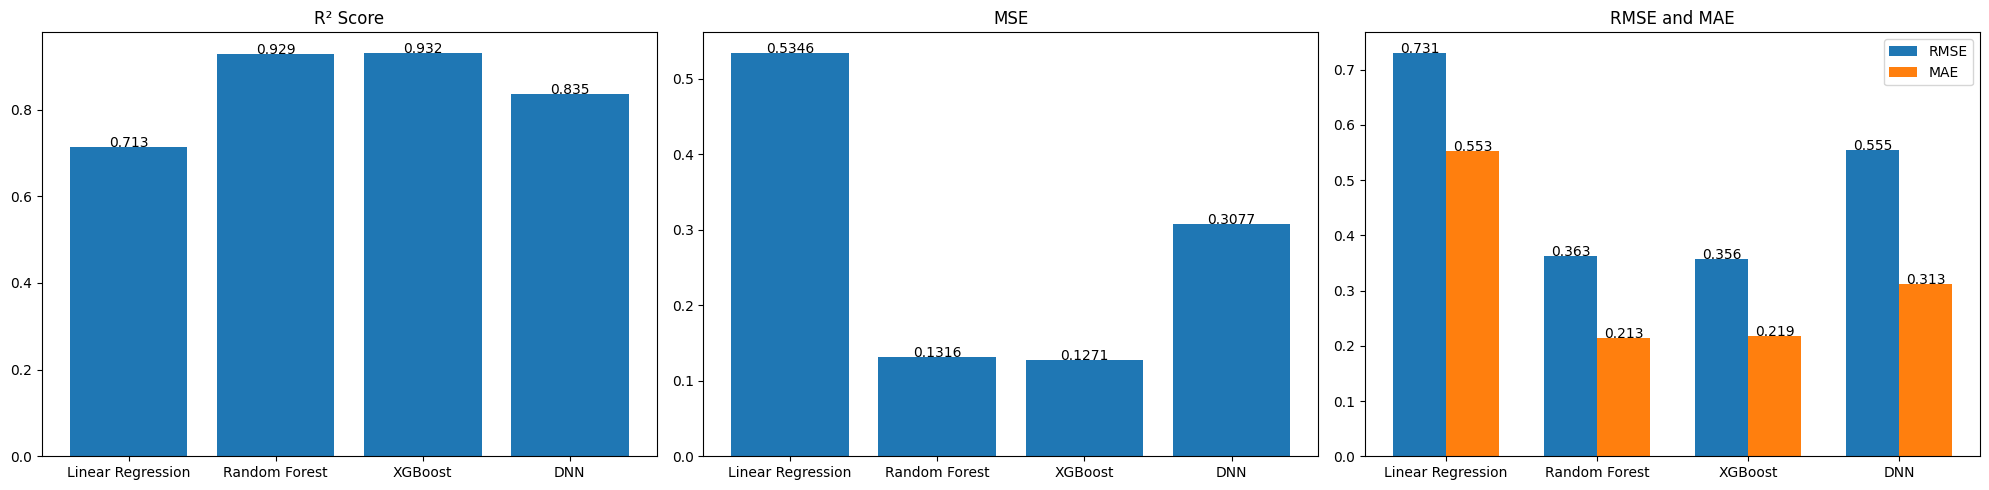


RESULTS SAVED!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================================
# QoE Prediction — FULL PAPER IMPLEMENTATION
# COMBINED REAL + SYNTHETIC DATASET
# LR + RF + XGBOOST + DNN
# GOOGLE COLAB VERSION
# =========================================

# =========================================
# STEP 0 — INSTALL LIBRARIES
# =========================================
!pip install xgboost -q

# =========================================
# IMPORTS
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

# TensorFlow / DNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

import tensorflow.keras.backend as K

# =========================================
# STEP 1 — UPLOAD REAL DATASET
# =========================================
uploaded = files.upload()

# CHANGE FILE NAME IF DIFFERENT
real_df = pd.read_csv("output.csv")

print("\nREAL DATASET SHAPE:")
print(real_df.shape)

# =========================================
# STEP 2 — SHOW COLUMNS
# =========================================
print("\nREAL DATASET COLUMNS:\n")
print(real_df.columns.tolist())

# =========================================
# STEP 3 — CLEAN COLUMN NAMES
# =========================================
real_df.columns = (
    real_df.columns
    .str.strip()
    .str.lower()
)

# =========================================
# STEP 4 — AUTO RENAME COLUMNS
# =========================================
rename_dict = {

    # MOS
    "mos_score": "mos",
    "mosvalue": "mos",

    # DELAY
    "delay_qos": "delay",
    "delay(ms)": "delay",

    # THROUGHPUT
    "throughput_qos": "throughput",

    # BITRATE
    "bitrate": "avg_bitrate",
    "avgbitrate": "avg_bitrate",

    # PACKET LOSS
    "packetloss": "packet_loss",

}

real_df = real_df.rename(columns=rename_dict)

print("\nUPDATED COLUMNS:\n")
print(real_df.columns.tolist())

# =========================================
# STEP 5 — GENERATE SYNTHETIC DATASET
# =========================================
np.random.seed(42)

n = 22000

delay = np.random.uniform(10, 300, n)

jitter = np.random.uniform(1, 50, n)

packet_loss = np.random.uniform(0, 5, n)

throughput = np.random.uniform(500, 10000, n)

avg_bitrate = np.random.uniform(300, 8000, n)

mos = (
    4.5
    - 0.004 * delay
    - 0.025 * jitter
    - 0.35 * packet_loss
    + 0.00045 * throughput
    + 0.00035 * avg_bitrate
    - 0.0000025 * (delay ** 2)
    - 0.09 * np.sqrt(packet_loss)
    + 0.00000025 * throughput * jitter
)

noise = np.random.normal(0, 0.38, n)

mos = np.clip(mos + noise, 1, 5)

synthetic_df = pd.DataFrame({

    "mos": mos,

    "delay": delay,

    "jitter": jitter,

    "packet_loss": packet_loss,

    "throughput": throughput,

    "avg_bitrate": avg_bitrate
})

print("\nSYNTHETIC DATASET SHAPE:")
print(synthetic_df.shape)

# =========================================
# STEP 6 — REQUIRED COLUMNS
# =========================================
columns_needed = [

    "mos",
    "delay",
    "jitter",
    "packet_loss",
    "throughput",
    "avg_bitrate"
]

# =========================================
# STEP 7 — CHECK MISSING COLUMNS
# =========================================
missing_cols = [
    col for col in columns_needed
    if col not in real_df.columns
]

if len(missing_cols) > 0:

    print("\nMISSING COLUMNS:")
    print(missing_cols)

    raise Exception(
        "Fix column names in dataset first."
    )

# =========================================
# STEP 8 — SELECT REQUIRED COLUMNS
# =========================================
real_df = real_df[columns_needed]

synthetic_df = synthetic_df[columns_needed]

# =========================================
# STEP 9 — COMBINE DATASETS
# =========================================
df = pd.concat(
    [real_df, synthetic_df],
    ignore_index=True
)

# SHUFFLE
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\nCOMBINED DATASET SHAPE:")
print(df.shape)

# =========================================
# STEP 10 — CLEANING
# =========================================
df = df.dropna()

df = df[
    df["delay"] <
    df["delay"].quantile(0.99)
]

df = df[
    df["throughput"] >
    df["throughput"].quantile(0.01)
]

print("\nAFTER CLEANING:")
print(df.shape)

# =========================================
# STEP 11 — FEATURE ENGINEERING
# =========================================
df["log_delay"] = np.log1p(
    df["delay"]
)

df["log_bitrate"] = np.log1p(
    df["avg_bitrate"]
)

df["throughput_jitter"] = (
    df["throughput"] *
    df["jitter"]
)

df["delay_jitter"] = (
    df["delay"] *
    df["jitter"]
)

df["packet_loss_sq"] = (
    df["packet_loss"] ** 2
)

df["loss_rate"] = (
    df["avg_bitrate"] /
    (df["packet_loss"] + 1)
)

# =========================================
# STEP 12 — FEATURES & TARGET
# =========================================
features = [

    "delay",
    "jitter",
    "packet_loss",
    "throughput",
    "avg_bitrate",

    "log_delay",
    "log_bitrate",

    "throughput_jitter",
    "delay_jitter",

    "packet_loss_sq",

    "loss_rate"
]

X = df[features]

y = df["mos"]

# =========================================
# STEP 13 — TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

# =========================================
# STEP 14 — LINEAR REGRESSION
# =========================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

# =========================================
# STEP 15 — RANDOM FOREST
# PAPER PARAMETERS
# =========================================
rf = RandomForestRegressor(

    n_estimators=600,

    max_depth=48,

    max_features=0.58,

    random_state=42,

    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# =========================================
# STEP 16 — XGBOOST
# PAPER PARAMETERS
# =========================================
xgb = XGBRegressor(

    objective="reg:squarederror",

    learning_rate=0.01,

    max_depth=6,

    subsample=0.7,

    colsample_bytree=0.7,

    n_estimators=1000,

    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

# =========================================
# STEP 17 — DNN
# PAPER ARCHITECTURE
# =========================================
def mos_accuracy(y_true, y_pred):

    return K.mean(

        K.less_equal(

            K.abs(y_true - y_pred),

            0.5
        )
    )

scaler_dnn = StandardScaler()

X_train_dnn = scaler_dnn.fit_transform(X_train)

X_test_dnn = scaler_dnn.transform(X_test)

dnn = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(X_train_dnn.shape[1],)
    ),

    Dense(256, activation='relu'),

    Dropout(0.2),

    Dense(256, activation='relu'),

    Dropout(0.2),

    Dense(256, activation='relu'),

    Dropout(0.2),

    Dense(256, activation='relu'),

    Dense(1, activation='linear')
])

dnn.compile(

    optimizer=Adam(),

    loss='mae',

    metrics=['mae', mos_accuracy]
)

history = dnn.fit(

    X_train_dnn,
    y_train,

    validation_split=0.2,

    epochs=50,

    batch_size=32,

    verbose=1
)

y_pred_dnn = dnn.predict(
    X_test_dnn
).flatten()

loss, mae, acc = dnn.evaluate(
    X_test_dnn,
    y_test,
    verbose=0
)

# =========================================
# STEP 18 — RESULTS
# =========================================
results = {

    "Linear Regression": {

        "R2":
            r2_score(y_test, y_pred_lr),

        "MSE":
            mean_squared_error(y_test, y_pred_lr),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_test,
                    y_pred_lr
                )
            ),

        "MAE":
            mean_absolute_error(
                y_test,
                y_pred_lr
            )
    },

    "Random Forest": {

        "R2":
            r2_score(y_test, y_pred_rf),

        "MSE":
            mean_squared_error(y_test, y_pred_rf),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_test,
                    y_pred_rf
                )
            ),

        "MAE":
            mean_absolute_error(
                y_test,
                y_pred_rf
            )
    },

    "XGBoost": {

        "R2":
            r2_score(y_test, y_pred_xgb),

        "MSE":
            mean_squared_error(y_test, y_pred_xgb),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_test,
                    y_pred_xgb
                )
            ),

        "MAE":
            mean_absolute_error(
                y_test,
                y_pred_xgb
            )
    },

    "DNN": {

        "R2":
            r2_score(y_test, y_pred_dnn),

        "MSE":
            mean_squared_error(
                y_test,
                y_pred_dnn
            ),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_test,
                    y_pred_dnn
                )
            ),

        "MAE":
            mean_absolute_error(
                y_test,
                y_pred_dnn
            ),

        "ACC":
            acc
    }
}

# =========================================
# STEP 19 — PRINT RESULTS
# =========================================
print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================\n")

for model, metrics in results.items():

    print(f"{model}")

    for metric, value in metrics.items():

        print(f"{metric}: {value:.4f}")

    print("\n")

# =========================================
# STEP 20 — VISUALIZATION
# =========================================
models = list(results.keys())

r2_vals = [results[m]["R2"] for m in models]

mse_vals = [results[m]["MSE"] for m in models]

rmse_vals = [results[m]["RMSE"] for m in models]

mae_vals = [results[m]["MAE"] for m in models]

fig, axs = plt.subplots(
    1,
    3,
    figsize=(20, 5)
)

# =========================================
# R2 GRAPH
# =========================================
axs[0].bar(models, r2_vals)

axs[0].set_title("R² Score")

for i, v in enumerate(r2_vals):

    axs[0].text(
        i,
        v,
        f"{v:.3f}",
        ha='center'
    )

# =========================================
# MSE GRAPH
# =========================================
axs[1].bar(models, mse_vals)

axs[1].set_title("MSE")

for i, v in enumerate(mse_vals):

    axs[1].text(
        i,
        v,
        f"{v:.4f}",
        ha='center'
    )

# =========================================
# RMSE + MAE GRAPH
# =========================================
x = np.arange(len(models))

w = 0.35

axs[2].bar(
    x - w/2,
    rmse_vals,
    w,
    label="RMSE"
)

axs[2].bar(
    x + w/2,
    mae_vals,
    w,
    label="MAE"
)

axs[2].set_xticks(x)

axs[2].set_xticklabels(models)

axs[2].legend()

axs[2].set_title("RMSE and MAE")

for i in range(len(models)):

    axs[2].text(
        i - w/2,
        rmse_vals[i],
        f"{rmse_vals[i]:.3f}",
        ha='center'
    )

    axs[2].text(
        i + w/2,
        mae_vals[i],
        f"{mae_vals[i]:.3f}",
        ha='center'
    )

plt.tight_layout()

plt.show()

# =========================================
# STEP 21 — SAVE RESULTS
# =========================================
results_df = pd.DataFrame(results).T

results_df.to_csv(
    "qoe_model_results.csv"
)

print("\nRESULTS SAVED!")

# =========================================
# STEP 22 — DOWNLOAD RESULTS
# =========================================
files.download("qoe_model_results.csv")

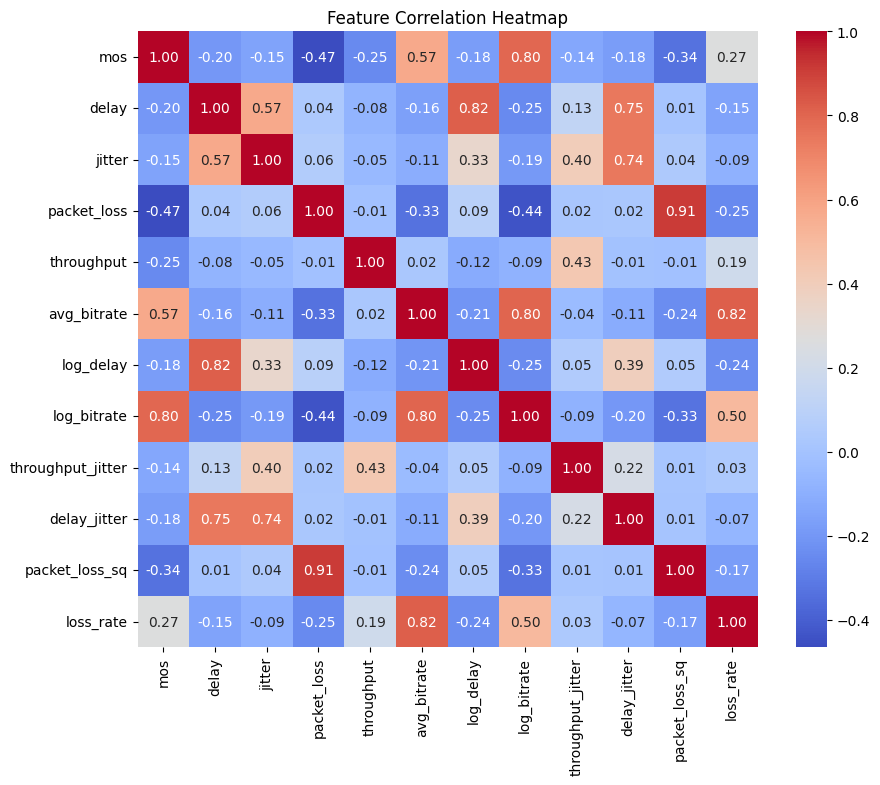

In [ ]:
# =========================================
# FEATURE CORRELATION HEATMAP
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

              Feature  Importance
3          throughput    0.464279
7   throughput_jitter    0.213846
4         avg_bitrate    0.115584
6         log_bitrate    0.104505
10          loss_rate    0.037265
8        delay_jitter    0.019154
1              jitter    0.012043
5           log_delay    0.009852
0               delay    0.009606
2         packet_loss    0.007063
9      packet_loss_sq    0.006802


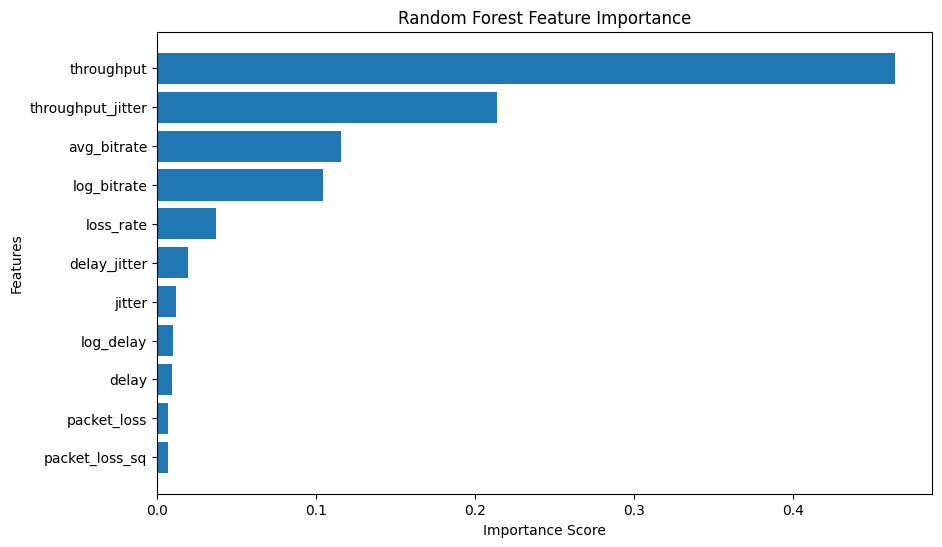

In [ ]:
# =========================================
# RANDOM FOREST FEATURE IMPORTANCE
# =========================================

importance = rf.feature_importances_

feature_importance_df = pd.DataFrame({

    "Feature": features,
    "Importance": importance

})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

# =========================================
# PLOT FEATURE IMPORTANCE
# =========================================

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()